<a href="https://colab.research.google.com/github/joury7766-spec/Urban-Heat-Island-Riyadh/blob/main/notebooks/uhi_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Install and import libraries


In [1]:
!pip install rasterio

In [2]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling
from google.colab import files


# 2. Upload raster files

In [3]:
uploaded = files.upload()

Saving Riyadh_LST.tif to Riyadh_LST.tif
Saving Riyadh_NDVI.tif to Riyadh_NDVI.tif
Saving Riyadh_Urban.tif to Riyadh_Urban.tif


# 3. Define file paths

In [5]:
LST_FILE = "Riyadh_LST.tif"
NDVI_FILE = "Riyadh_NDVI.tif"
URBAN_FILE = "Riyadh_Urban.tif"

# 4. Inspect raster metadata

In [6]:
def inspect_raster(file_path: str) -> None:
    with rasterio.open(file_path) as src:
        print(f"FILE: {file_path}")
        print("  shape:", src.read(1).shape)
        print("  bands:", src.count)
        print("  crs:", src.crs)
        print("  transform:", src.transform)
        print("-" * 40)

for file_path in [LST_FILE, NDVI_FILE, URBAN_FILE]:
    inspect_raster(file_path)



FILE: Riyadh_LST.tif
  shape: (2973, 3711)
  bands: 1
  crs: EPSG:4326
  transform: | 0.00, 0.00, 46.20|
| 0.00,-0.00, 25.20|
| 0.00, 0.00, 1.00|
----------------------------------------
FILE: Riyadh_NDVI.tif
  shape: (2973, 3711)
  bands: 1
  crs: EPSG:4326
  transform: | 0.00, 0.00, 46.20|
| 0.00,-0.00, 25.20|
| 0.00, 0.00, 1.00|
----------------------------------------
FILE: Riyadh_Urban.tif
  shape: (10017, 10956)
  bands: 1
  crs: EPSG:4326
  transform: | 0.00, 0.00, 46.18|
| 0.00,-0.00, 25.16|
| 0.00, 0.00, 1.00|
----------------------------------------


# 5. Load LST raster and visualize

LST shape: (2973, 3711)
Number of pixels: 11032803
Min LST: 24.2994634946497
Max LST: 51.746671414862426
Mean LST: 41.064839267064514


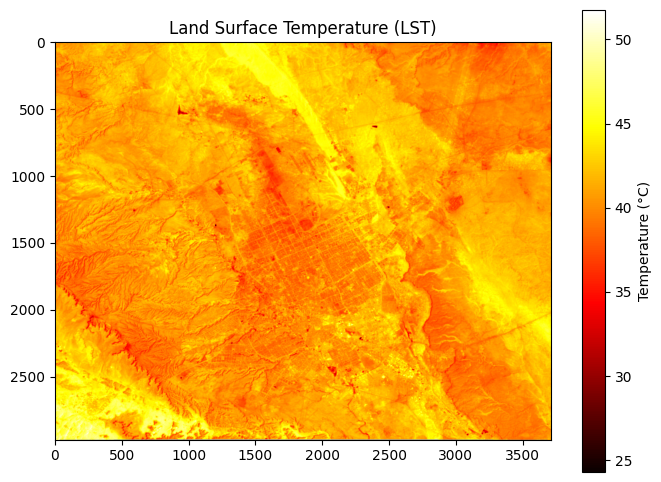

In [7]:
with rasterio.open(LST_FILE) as src:
    lst = src.read(1)
    lst_transform = src.transform
    lst_crs = src.crs
    lst_shape = lst.shape

print("LST shape:", lst.shape)
print("Number of pixels:", lst.size)
print("Min LST:", np.nanmin(lst))
print("Max LST:", np.nanmax(lst))
print("Mean LST:", np.nanmean(lst))

plt.figure(figsize=(8, 6))
plt.imshow(lst, cmap="hot")
plt.colorbar(label="Temperature (°C)")
plt.title("Land Surface Temperature (LST)")
plt.show()


# 6. Convert LST raster to tabular dataset

In [8]:
rows, cols = np.where(~np.isnan(lst))

latitudes = []
longitudes = []
temperatures = []

for row, col in zip(rows, cols):
    lon, lat = rasterio.transform.xy(lst_transform, row, col)
    latitudes.append(lat)
    longitudes.append(lon)
    temperatures.append(lst[row, col])

lst_df = pd.DataFrame({
    "latitude": latitudes,
    "longitude": longitudes,
    "LST": temperatures
})

print(lst_df.head())
print("LST dataframe shape:", lst_df.shape)



    latitude  longitude        LST
0  25.200843  46.562601  45.872850
1  25.200843  46.562870  45.872850
2  25.200843  46.563140  45.849778
3  25.200843  46.563409  45.803657
4  25.200843  46.563679  45.762284
LST dataframe shape: (11019740, 3)


# 7. Sample data for EDA

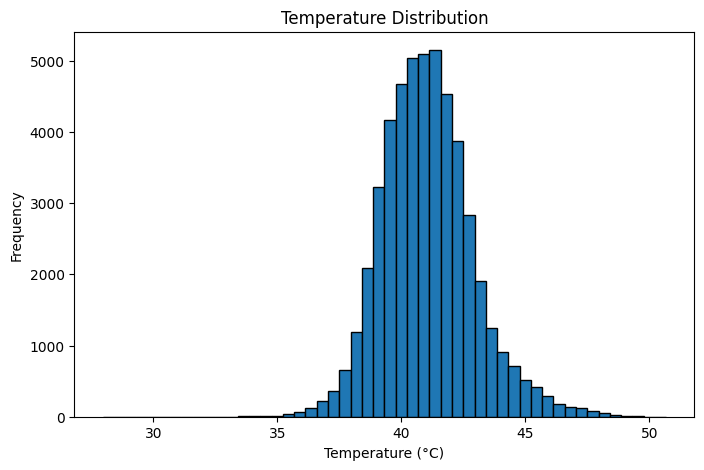

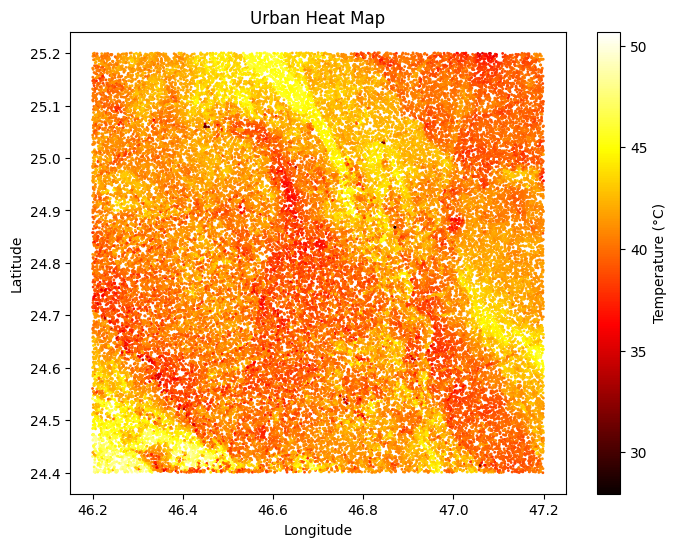

In [9]:
lst_sample = lst_df.sample(n=50000, random_state=42)

plt.figure(figsize=(8, 5))
plt.hist(lst_sample["LST"], bins=50, edgecolor="black")
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(
    lst_sample["longitude"],
    lst_sample["latitude"],
    c=lst_sample["LST"],
    cmap="hot",
    s=1
)
plt.colorbar(label="Temperature (°C)")
plt.title("Urban Heat Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



# 8. Load NDVI and Urban rasters

In [10]:
with rasterio.open(NDVI_FILE) as src:
    ndvi = src.read(1)

with rasterio.open(URBAN_FILE) as src:
    urban_raw = src.read(1)
    urban_transform = src.transform
    urban_crs = src.crs

print("NDVI shape:", ndvi.shape)
print("Urban raw shape:", urban_raw.shape)



NDVI shape: (2973, 3711)
Urban raw shape: (10017, 10956)


# 9. Resample Urban raster to match LST

In [11]:
urban_resampled = np.empty(lst_shape, dtype=np.float32)

reproject(
    source=urban_raw,
    destination=urban_resampled,
    src_transform=urban_transform,
    src_crs=urban_crs,
    dst_transform=lst_transform,
    dst_crs=lst_crs,
    resampling=Resampling.nearest
)

print("Urban resampled shape:", urban_resampled.shape)


Urban resampled shape: (2973, 3711)


# 10. Clean and merge data

In [12]:
mask = (
    ~np.isnan(lst) &
    ~np.isnan(ndvi) &
    ~np.isnan(urban_resampled)
)

lst_clean = lst[mask]
ndvi_clean = ndvi[mask]
urban_clean = urban_resampled[mask]

final_df = pd.DataFrame({
    "LST": lst_clean,
    "NDVI": ndvi_clean,
    "Urban": urban_clean
})

print(final_df.head())
print("Final dataset shape:", final_df.shape)


         LST      NDVI  Urban
0  45.872850  0.087340    0.0
1  45.872850  0.087340    0.0
2  45.849778  0.086091    0.0
3  45.803657  0.085258    0.0
4  45.762284  0.083815    0.0
Final dataset shape: (11019740, 3)


# 11. Save final dataset

In [13]:
final_df.to_csv("UHI_dataset.csv", index=False)
print("Saved: UHI_dataset.csv")

Saved: UHI_dataset.csv
